<a href="https://colab.research.google.com/github/DamianGit111/Elevator-Problem/blob/main/Grade_inflation_math_modeling_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

We need to generate distributions for each one of our class scenarios (A, A-, B+, B, and B-) averages.

[np.float64(4.158885651615458), np.float64(3.8191672937680465), np.float64(4.217116047947022), np.float64(4.099056251492048), np.float64(2.8209706518866153), np.float64(4.286806265304943), np.float64(4.149387690614319), np.float64(4.167683949815211), np.float64(3.0199686015186797), np.float64(3.8353216244106325), np.float64(3.7127934851656157), np.float64(4.259059932352106), np.float64(4.052358100290811), np.float64(4.193365758093905), np.float64(3.82559078632626), np.float64(3.3956768066886065), np.float64(3.963184334972559), np.float64(2.575751161177213), np.float64(4.196667446649313), np.float64(4.041060190556452), np.float64(4.1470971610669665), np.float64(3.684168910310316), np.float64(4.284090204172526), np.float64(4.238859104786597), np.float64(4.162122204820523), np.float64(3.2940681814253576), np.float64(3.8574722628809734), np.float64(2.3480459669718337), np.float64(3.1415418876951042), np.float64(4.086989138256049), np.float64(4.136963028719466), np.float64(4.282322331482329

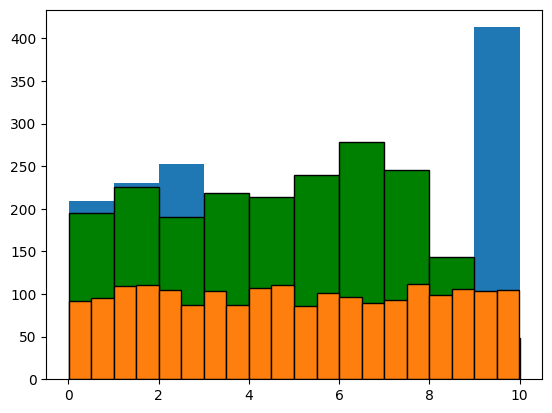

noise only (no class inflation) overlap: 0.51


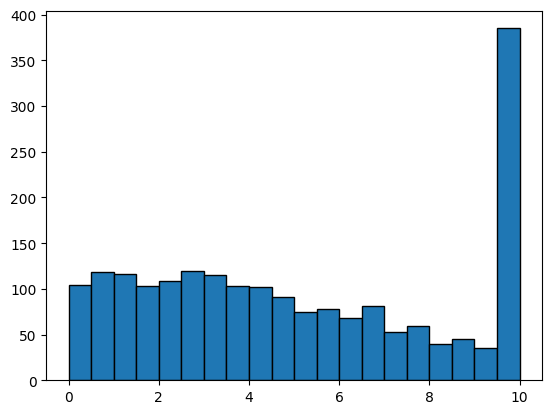

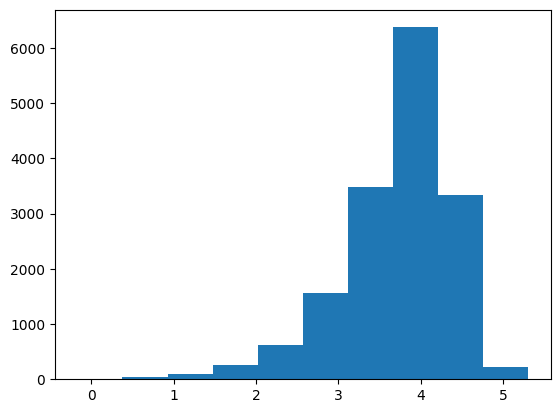

0 -184.20680743952366
1 -75.24378807204593
2 -36.502301783937554
3 -21.679432923965063
4 -14.695475603044603
5 -11.178317409187429
6 -9.43405165389548
7 -8.675825484266152
8 -8.494849076555639
9 -8.662084128825896
10 -9.04213232863355
7.94


calc estimated student merit: 100%|██████████| 2000/2000 [09:15<00:00,  3.60it/s]


0.08
0.023441699249474212


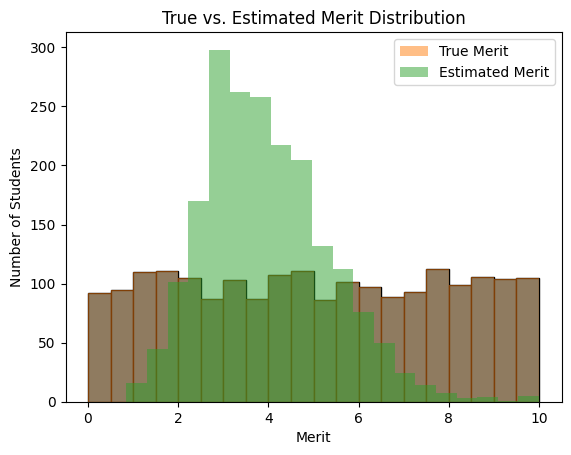

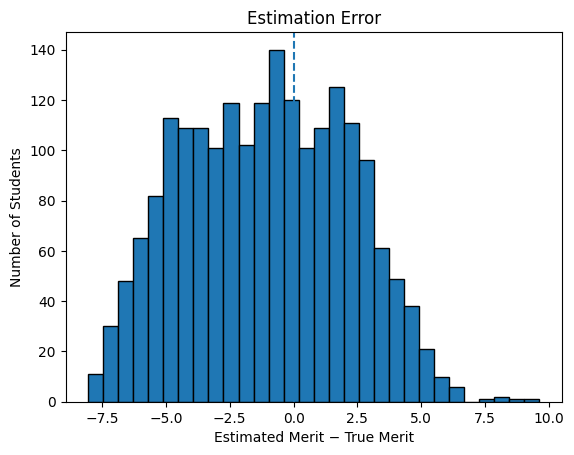

In [ ]:
import math
import statistics
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm

k=8
shift = 0 # shifting grades up by a constant because adding positive noise will clip high grades to 4.3 and will decrease other high grades
rng = np.random.default_rng(seed=42)
uniform_dist = rng.uniform(low=0, high=10, size=2000)
student_id = np.tile(np.arange(2000), k)
class_of = rng.permutation(np.arange(2000 * k) % 40)
zeta = rng.normal(0, 0.04, 40)
normal_dist = rng.normal(loc=0, scale=0.3, size=2000 * k)

# normal_dist = np.random.normal(loc=2.15, scale=1.0, size=1000)
def pass_through_merit_equation(l):
  new_list = []
  for x in l:
    # equation
    newval = -math.e**(-0.808253568*(x**0.346175237 - 2.029772825))+5.158114612
    new_list.append(newval)
  return new_list

print(pass_through_merit_equation(uniform_dist))


def add_noise(l, n):
  new_list = []
  for x in range(0,len(l)):
    newval = l[x] + n[x]
    new_list.append(newval)
  return new_list

# print(pass_through_merit_equation(uniform_dist))
# print(statistics.mean(pass_through_merit_equation(uniform_dist)))
# print(len(normal_dist))
# print(statistics.mean(normal_dist))
possible_grades = [0, 0.7, 1, 1.3, 1.7, 2, 2.3, 2.7, 3, 3.3, 3.7, 4, 4.3]
noised = add_noise(pass_through_merit_equation(uniform_dist[student_id]), normal_dist)
noised = np.array(noised) + zeta[class_of] + shift
print(sum(x>4.3 for x in noised))
noised = np.clip(noised, 0, 4.3)
print(any(x>4.3 for x in noised))
noised = np.array(possible_grades)[np.abs(noised[:, None] - np.array(possible_grades)).argmin(1)]
print(statistics.mean(noised))
# print(type(noised))
print(noised[0:10])
print(max(noised))
print(noised.tolist().count(4.3))
# plt.hist(noised, bins=[x-0.1 for x in possible_grades] + [4.4])


classes = []
zero_counter = 0
classes_indiv = [[] for _ in range(40)]

def form_classes():
  global zero_counter
  for j, grade in enumerate(noised):
      i = class_of[j]
      classes_indiv[i].append(str(i) + ", " + str(grade))
  return classes_indiv
classes_indiv = form_classes()

means = []
for cls in classes_indiv:
  parsed_cls = []
  for item in cls:
    parsed_cls.append(float(item[3:]))
  means.append(statistics.mean(parsed_cls))
# print(means)
# print(statistics.mean(means))
inf_factor = [i - statistics.mean(means) for i in means]

# print(inf_factor)

def eval_inverse_omega(val):
    return (2.029772825 - math.log(5.158114612 - val) / 0.808253568) ** (1 / 0.346175237)

def pass_through_inverses(l):
  new_list = []
  for x in l:
    new_list.append(eval_inverse_omega(x))
  return new_list

test = pass_through_inverses(np.clip(add_noise(pass_through_merit_equation(uniform_dist), normal_dist), 0, 4.3))
plt.hist(test)

adjusted = noised - np.array(inf_factor)[class_of]
gpa = np.bincount(student_id, weights=adjusted) / k - shift
#By decile
final_merits = [eval_inverse_omega(np.clip(g, 0, 4.3)) for g in gpa]
#By % (sort by gpa)
# final_merits = 10 * (np.argsort(np.argsort(gpa)) + 0.5) / len(gpa)
temp_counter = 0
for x in final_merits:
  if x >= 9:
    temp_counter +=1
print(temp_counter/2000)
plt.hist(final_merits, color='green', edgecolor='black')

top_true = uniform_dist >= np.quantile(uniform_dist, 0.9)
top_hat = np.array(final_merits) >= np.quantile(final_merits, 0.9)
print("top-decile overlap:", (top_true & top_hat).sum() / top_true.sum())
print("inflation estimate corr:", np.corrcoef(zeta, inf_factor)[0, 1])

print(any(x >= 9 for x in final_merits))
raw_gpa = np.bincount(student_id, weights=noised) / k
top_raw_hat = raw_gpa >= np.quantile(raw_gpa, 0.9)
print("raw gpa top-decile overlap:", (top_true & top_raw_hat).sum() / top_true.sum())
#no noise or class inflation
B_values = np.array(pass_through_merit_equation(uniform_dist))
recovered = np.array([eval_inverse_omega(x) for x in B_values])
top_ideal_hat = recovered >= np.quantile(recovered, 0.9)
print("ideal scenario (no noise) overlap:", (top_true & top_ideal_hat).sum() / top_true.sum())
plt.hist(recovered, bins=20, edgecolor="black")
plt.show()
#noise no class inflation
raw = B_values + rng.normal(0, 0.3, 2000)
recovered = np.array([eval_inverse_omega(np.clip(x, 0, 4.3)) for x in raw])
top_noise_hat = recovered >= np.quantile(recovered, 0.9)
print("noise only (no class inflation) overlap:", (top_true & top_noise_hat).sum() / top_true.sum())
plt.hist(recovered, bins=20, edgecolor="black")
plt.show()
B_values = np.array(pass_through_merit_equation(uniform_dist))
raw = B_values[student_id] + normal_dist
plt.hist(raw)
plt.show()

def likelihood_estimator(omega, grades, classes, zeta_hat, stdev=0.3):
  possible_grades = np.array([0, 0.7, 1, 1.3, 1.7, 2, 2.3, 2.7, 3, 3.3, 3.7, 4, 4.3])
  grade = pass_through_merit_equation([omega])[0] + zeta_hat[classes]
  grade_indices = np.searchsorted(possible_grades, grades)
  edges = np.empty(len(possible_grades) + 1)
  edges[0] = -np.inf
  edges[1:-1] = (possible_grades[:-1] + possible_grades[1:]) / 2
  edges[-1] = np.inf
  lower = edges[grade_indices]
  upper = edges[grade_indices + 1]
  probabilities = stats.norm.cdf((upper-grade)/stdev)-stats.norm.cdf((lower-grade)/stdev)
  probabilities = np.maximum(probabilities, 1e-10)
  log_likelihood = np.sum(np.log(probabilities))
  return log_likelihood


omegas = np.linspace(0, 10, 1001)
log_likelihoods = [likelihood_estimator(omega, [3.7, 4, 4, 4.3, 4.3, 4.3, 4.3, 4], [12, 4, 5, 19, 30, 10, 39, 1], np.array(inf_factor)) for omega in omegas]
for omega in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    ll = likelihood_estimator(omega, [3.7, 4, 4, 4.3, 4.3, 4.3, 4.3, 4], [12, 4, 5, 19, 30, 10, 39, 1], np.array(inf_factor))
    print(omega, ll)
print(omegas[np.argmax(log_likelihoods)])
estimated_omegas=[]
for i in tqdm(range(2000), desc="calc estimated student merit"):
  grades = noised[i*k:(i+1)*k]
  classes = class_of[i*k:(i+1)*k]
  log_likelihoods = [likelihood_estimator(omega, grades, classes, np.array(inf_factor)) for omega in omegas]
  estimated_omegas.append(omegas[np.argmax(log_likelihoods)])

estimated_omegas = np.array(estimated_omegas)
plt.hist(uniform_dist, bins=20, edgecolor="black")
top_true = uniform_dist >= np.quantile(uniform_dist, 0.9)
top_hat = estimated_omegas >= np.quantile(estimated_omegas, 0.9)
top_decile_overlap = (top_true & top_hat).sum() / top_true.sum()
print(top_decile_overlap)
print(stats.spearmanr(uniform_dist, estimated_omegas).statistic)
plt.hist(uniform_dist, bins=20, alpha=0.5, label="True Merit")
plt.hist(estimated_omegas, bins=20, alpha=0.5, label="Estimated Merit")
plt.xlabel("Merit")
plt.ylabel("Number of Students")
plt.title("True vs. Estimated Merit Distribution")
plt.legend()
plt.show()
error = estimated_omegas-uniform_dist
plt.hist(error, bins=30, edgecolor="black")
plt.axvline(0, linestyle="--")
plt.xlabel("Estimated Merit − True Merit")
plt.ylabel("Number of Students")
plt.title("Estimation Error")
plt.show()


TypeError: 'float' object is not subscriptable

O

10000


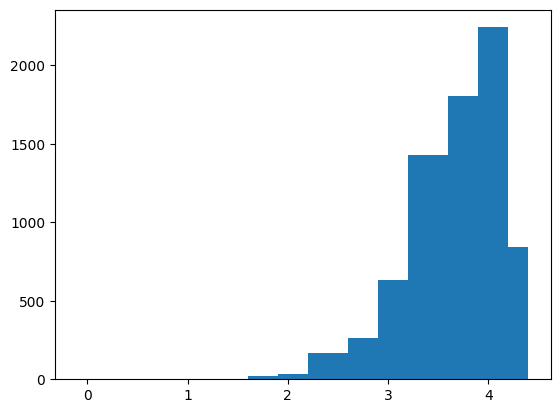

2565
3.700887295453709
7435
[np.float64(3.288412118392232), np.float64(3.5649337868085427), np.float64(3.694908203424526), np.float64(4.167404360621447), np.float64(3.0059875832947456), np.float64(3.6189928350564857), np.float64(3.0672991408787773), np.float64(3.509171458271533), np.float64(3.7088941893793463), np.float64(4.000688215872065), np.float64(3.318201661768077), np.float64(2.9820008828180633), np.float64(3.7662423063516663), np.float64(2.958314108623053), np.float64(3.4642198610771997), np.float64(3.6479806928684617), np.float64(4.209913478692547), np.float64(4.059098869399902), np.float64(4.2200576677165715), np.float64(3.9409127065977256)]
0.4169468728984532% of people with a C or less
8.94418291862811% of people with a B or less
3.700887295453709


In [ ]:
import numpy as np
from scipy.stats import skewnorm
import statistics
import matplotlib.pyplot as plt
import math

possible_grades = [0, 0.7, 1, 1.3, 1.7, 2, 2.3, 2.7, 3, 3.3, 3.7, 4, 4.3]

a_skew = -12
mean = 3.89
variance = 0.28
scale = math.sqrt(variance / (1-(2*a_skew**2)/(np.pi*(1+a_skew**2))))
loc = mean-(scale*a_skew*math.sqrt(2/np.pi))/math.sqrt(1+a_skew**2)
data = skewnorm.rvs(a_skew, loc, scale=scale, size=10000)
invalid_count = 0
print(len(data))

for x in data:
  # x += 1
  if x > 4.3 or x < 0:
    # print("error/invalid gpa")
    invalid_count += 1



# data = np.clip(data, 0, 4.3)
shift = 0
data = [x + shift for x in data if x < 4.3 - shift and x > -shift]
plt.hist(data, bins=[x-0.1 for x in possible_grades] + [4.4])
# closest_indices = np.abs(data[:, None] - possible_grades).argmin(axis=1)

plt.show()
# def gen_dist():
print(invalid_count)
print(statistics.mean(data))
print(len(data))
print(data[0:20])
print(str(sum(1 for x in data if x <= 2)/len(data)*100) + "% of people with a C or less")
print(str(sum(1 for x in data if x <= 3)/len(data)*100) + "% of people with a B or less")
print(statistics.mean(data))





Simulating Grid: 100%|██████████| 10000/10000 [00:58<00:00, 169.96run/s]


ERROR SUMMARY 
Total Enrolled Grades Processed: 16,000
Median Grid Error:  0.022256
Mean Grid Error:    0.027290
Min Grid Error:     0.000000
Max Grid Error:     0.144150


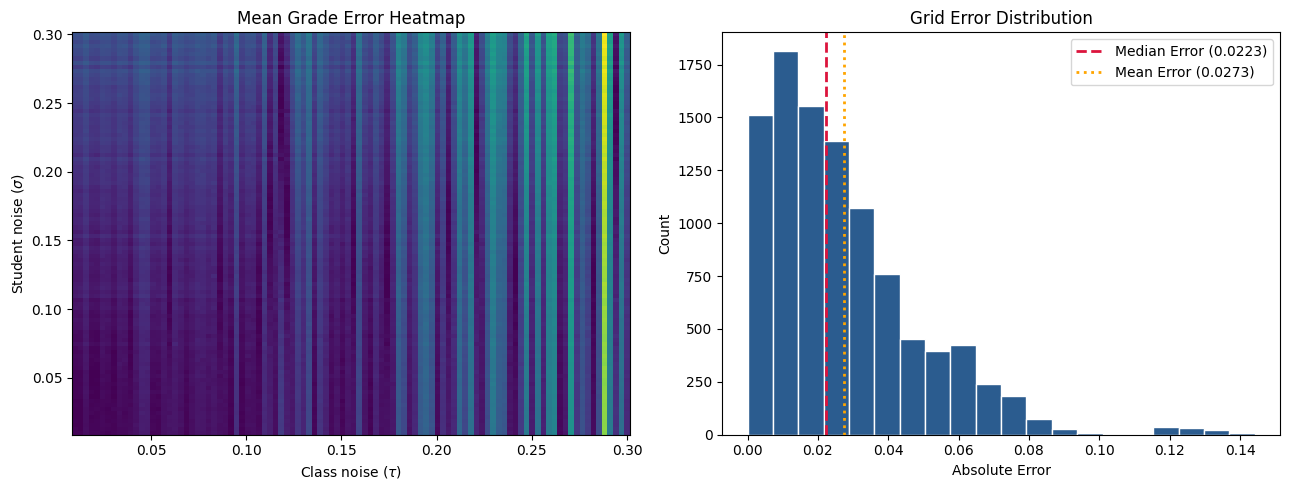

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root
from scipy.integrate import quad
from tqdm import tqdm

G_POINTS = np.array([0.0, 0.7, 1.0, 1.3, 1.7, 2.0, 2.3, 2.7, 3.0, 3.3, 3.7, 4.0, 4.3])
MIDPOINTS = (G_POINTS[:-1] + G_POINTS[1:]) / 2.0
TARGET_MEAN = 3.7


def B(w, a, lam, b, c):
    return -np.exp(-a * (np.power(w, lam) - b)) + c


def fit_baseline():
    def system(p):
        a, lam, b, c = p
        return [
            B(0, a, lam, b, c) - 0.0,
            B(10, a, lam, b, c) - 4.3,
            B(5, a, lam, b, c) - 3.9,
            quad(B, 0, 10, args=(a, lam, b, c))[0] - 37.0,
        ]

    res = root(system, [0.81, 0.35, 2.03, 5.16], method="hybr", tol=1e-12)
    return res.x


def round_grades(psi):
    return G_POINTS[np.digitize(psi, MIDPOINTS)]


a, lam, b, c = fit_baseline()

n_students, n_classes, classes_per_student = 2000, 50, 8
sigmas = np.linspace(0.01, 0.3, 100)
taus = np.linspace(0.01, 0.3, 100)

np.random.seed(42)
omega = np.random.uniform(0, 10, n_students)
base_g = B(omega, a, lam, b, c)

enrollment_mask = np.zeros((n_students, n_classes), dtype=bool)
for i in range(n_students):
    chosen_classes = np.random.choice(n_classes, size=classes_per_student, replace=False)
    enrollment_mask[i, chosen_classes] = True

raw_zeta = np.random.normal(0, 1, (len(taus), n_classes))
raw_eps = np.random.normal(0, 1, (len(sigmas), n_students, n_classes))

errors = np.zeros((len(sigmas), len(taus)))

total_runs = len(sigmas) * len(taus)
with tqdm(total=total_runs, desc="Simulating Grid", unit="run") as pbar:
    for i, s in enumerate(sigmas):
        for j, t in enumerate(taus):
            psi = base_g[:, None] + raw_zeta[j] * t + raw_eps[i] * s
            G = round_grades(psi)

            enrolled_G = G[enrollment_mask]
            errors[i, j] = np.abs(enrolled_G.mean() - TARGET_MEAN)
            pbar.update(1)

median_err = np.median(errors)
mean_err = np.mean(errors)

print("ERROR SUMMARY ")
print(f"Total Enrolled Grades Processed: {n_students * classes_per_student:,}")
print(f"Median Grid Error:  {median_err:.6f}")
print(f"Mean Grid Error:    {mean_err:.6f}")
print(f"Min Grid Error:     {np.min(errors):.6f}")
print(f"Max Grid Error:     {np.max(errors):.6f}")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
T, S = np.meshgrid(taus, sigmas)

cbar = ax1.pcolormesh(T, S, errors, cmap="viridis", shading="auto")
ax1.set_xlabel(r"Class noise ($\tau$)")
ax1.set_ylabel(r"Student noise ($\sigma$)")
ax1.set_title("Mean Grade Error Heatmap")

ax2.hist(errors.ravel(), bins=20, color="#2b5c8f", edgecolor="white")
ax2.axvline(
    median_err,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Median Error ({median_err:.4f})",
)
ax2.axvline(
    mean_err,
    color="orange",
    linestyle=":",
    linewidth=2,
    label=f"Mean Error ({mean_err:.4f})",
)
ax2.set_xlabel("Absolute Error")
ax2.set_ylabel("Count")
ax2.set_title("Grid Error Distribution")
ax2.legend()

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from scipy.optimize import minimize
from scipy.special import ndtr, logsumexp
from scipy.stats import norm
from tqdm import tqdm

GRADE_POINTS = np.array([0.0, 0.7, 1.0, 1.3, 1.7, 2.0, 2.3, 2.7, 3.0, 3.3, 3.7, 4.0, 4.3])

NUM_OF_STUDENTS = 2000
NUM_OF_CLASSES = 50
CLASSES_PER_STUDENT = 8

rng = np.random.default_rng(seed=67)


## 6.1.6
AP, LAM, OFF, CP = 0.808253568, 0.346175237, 2.029772825, 5.158114612

def B(omega):
    return CP - np.exp(-AP * (np.asarray(omega) ** LAM - OFF))

TRUE_TAU = 0.3
TRUE_SIGMA = 0.2
TRUE_MERITS = rng.uniform(0, 10, NUM_OF_STUDENTS)                                   # (N)
TRUE_CLASS_EFFECTS = rng.normal(0, TRUE_TAU, NUM_OF_CLASSES)                             # (K)
TRUE_EPSILONS = rng.normal(0, TRUE_SIGMA, (NUM_OF_STUDENTS, CLASSES_PER_STUDENT))        # (N, m)

CLASS_ASSIGNMENTS = rng.random((NUM_OF_STUDENTS, NUM_OF_CLASSES)).argsort(axis=1)[:, :CLASSES_PER_STUDENT]  # (N, m)

## 6.1.1: psi = B(omega) + zeta + eps
TRUE_PSIS = (B(TRUE_MERITS)[:, None]
             + TRUE_CLASS_EFFECTS[CLASS_ASSIGNMENTS]
             + TRUE_EPSILONS)                                                       # (N, m)

## round to nearest grade point
OBSERVED_GS = GRADE_POINTS[np.abs(TRUE_PSIS[..., None] - GRADE_POINTS).argmin(-1)]  # (N, m)

# normal pdf
INV_SQRT_2PI = 1 / np.sqrt(2 * np.pi)
def pdf(x):
    return np.exp(-0.5 * x**2) * INV_SQRT_2PI

K = NUM_OF_CLASSES

# index of grade point bucket by student, ie. F = 0, D = 1, C- = 2, ..., A = 11, A+ = 12
idx = np.abs(OBSERVED_GS[..., None] - GRADE_POINTS).argmin(-1)                      # (N, m)


# 14 edges of boxes, average of adjacent grade points with infinities
bounds = np.concatenate([[-np.inf],
                         (GRADE_POINTS[:-1] + GRADE_POINTS[1:]) / 2,
                         [np.inf]])

# precomputation of bounds for each student, lo and hi grade points that would round
LO = bounds[idx][:, None, :]
HI = bounds[idx + 1][:, None, :]

# precomputation of B for 400 grid points in omega space
W = np.linspace(0, 10, 400)
BW = B(W)[None, :, None]                                                            # (1, G, 1)

LOG_G = np.log(len(W))


## 6.2.9: negative log posterior over zeta
def fullL_629(zeta, sigma, tau):
    mu = BW + zeta[CLASS_ASSIGNMENTS][:, None, :]                                   # B(omega) + zeta for each student and class assignment (N, G, m), mean of distribution in 6.2.2

    a = (LO - mu) / sigma
    b = (HI - mu) / sigma

    P = np.clip(ndtr(b) - ndtr(a), 1e-300, None)                                    # 6.2.3, clip bottom to avoid log(0) in next step

    ll = np.log(P).sum(axis=2)                                                      # 6.2.5, (N, G)
    lse = logsumexp(ll, axis=1)                                                     # 6.2.6 (sum, divide by num in next step to integrate)

    val = -(lse - LOG_G).sum() - norm.logpdf(zeta, 0, tau).sum()                    # 6.2.7 + prior, log g here to divide by number of things summed

    return val


# ---------------- 6.2.9 ----------------

def step_62_optimize(sigma,tau):
    MAXITER = 200
    pbar = tqdm(total=MAXITER, desc="L-BFGS-B")

    def callback(xk):
        pbar.update(1)
        pbar.set_postfix(nlp=f"{fullL_629(xk, sigma, tau):.2f}")

    res = minimize(
        fullL_629,
        np.zeros(K),
        args=(sigma, tau),
        method="L-BFGS-B",
        callback=callback,
        options={"maxiter": MAXITER},
    )
    pbar.close()

    zeta_hat = res.x
    print(res.success, res.message, res.fun)
    print("corr with true:", np.corrcoef(zeta_hat, TRUE_CLASS_EFFECTS)[0, 1])
    print("mean zeta_hat:", zeta_hat.mean(), " std:", zeta_hat.std(), " (true tau:", tau, ")")

    return zeta_hat


# ---------------- 6.3 ----------------
# ## 6.3.2: negative log-likelihood of student i's grades at merit omega, given zeta'
# def studentL_633(omega, i, zetas_prime, sigma):
#     omega = float(np.atleast_1d(omega)[0])
#     mu = B(omega) + zetas_prime[CLASS_ASSIGNMENTS[i]]

#     a = (LO[i, 0] - mu) / sigma
#     b = (HI[i, 0] - mu) / sigma

#     P = np.clip(ndtr(b) - ndtr(a), 1e-300, None)                 # 6.2.3
#     return -np.log(P).sum()                                      # 6.3.1, scalar

# ## 6.3.3: maximize over omega for one student
# def step_63_optimize(i, zetas_prime, sigma):
#     mu = BW[0] + zetas_prime[CLASS_ASSIGNMENTS[i]][None, :]
#     P = np.clip(ndtr((HI[i, 0] - mu) / sigma) - ndtr((LO[i, 0] - mu) / sigma), 1e-300, None)
#     x0 = W[np.log(P).sum(axis=1).argmax()]

#     res = minimize(
#         studentL_633,
#         np.array([x0]),
#         args=(i, zetas_prime, sigma),
#         method="L-BFGS-B",
#         bounds=[(0, 10)],
#     )
#     omega_hat = res.x[0]
#     print(res.success, res.message, res.fun)
#     print("true merit:", TRUE_MERITS[i], " estimated merit:", omega_hat)
#     return omega_hat


def all_merits_633(zetas_prime, sigma):
    mu = BW + zetas_prime[CLASS_ASSIGNMENTS][:, None, :]
    P = np.clip(ndtr((HI - mu) / sigma) - ndtr((LO - mu) / sigma), 1e-300, None)
    ll = np.log(P).sum(axis=2)
    return W[ll.argmax(axis=1)]


import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ---------------- 6.4 ----------------

## 6.4.1: Derivation of tau with variance correction: E[zeta_k^2] = E[zeta_k]^2 + Var(zeta_k)
def estimate_tau_with_variance_correction(zetas_prime, sigma, tau, eps=1e-4):
    K = len(zetas_prime)
    f0 = fullL_629(zetas_prime, sigma, tau)

    # Compute the diagonal of the Hessian matrix (2nd derivatives wrt each zeta_k)
    hessian_diag = np.zeros(K)
    for k in range(K):
        z_plus = zetas_prime.copy()
        z_minus = zetas_prime.copy()
        z_plus[k] += eps
        z_minus[k] -= eps

        f_plus = fullL_629(z_plus, sigma, tau)
        f_minus = fullL_629(z_minus, sigma, tau)

        hessian_diag[k] = (f_plus - 2 * f0 + f_minus) / (eps ** 2)

    # Posterior variance Var(zeta_k) ≈ 1 / H_kk
    var_zetas = 1.0 / np.maximum(hessian_diag, 1e-8)

    # Equation 6.4.1: E[zeta_k^2] = E[zeta_k]^2 + Var(zeta_k)
    e_zeta_sq = zetas_prime**2 + var_zetas

    # tau = sqrt( Var(E[zeta]) + mean(Var(zeta_k)) )
    tau_hat = np.sqrt(np.maximum(0, np.var(zetas_prime) + np.mean(var_zetas)))
    return tau_hat, var_zetas

## 6.4.2 & 6.4.3: Negative log-likelihood of student grades as a function of sigma
def sigma_neg_log_likelihood(sigma, zetas_prime, omega_prime):
    sigma = float(np.atleast_1d(sigma)[0])

    # Mean grade baseline + class inflation: shape (N, m)
    mu = B(omega_prime)[:, None] + zetas_prime[CLASS_ASSIGNMENTS]

    lo = bounds[idx]
    hi = bounds[idx + 1]

    a = (lo - mu) / sigma
    b = (hi - mu) / sigma

    P = np.clip(ndtr(b) - ndtr(a), 1e-300, None)
    return -np.log(P).sum()

## 6.4 Optimization step
def step_64_optimize(zetas_prime, omega_prime, current_sigma=0.15, current_tau=0.15):
    tau_hat, var_zetas = estimate_tau_with_variance_correction(zetas_prime, current_sigma, current_tau)

    res = minimize(
        sigma_neg_log_likelihood,
        x0=np.array([current_sigma]),
        args=(zetas_prime, omega_prime),
        method="L-BFGS-B",
        bounds=[(1e-4, 5.0)]
    )

    sigma_hat = res.x[0]

    print("Sigma Optimization Success:", res.success, f"({res.message})")
    print(f"Mean Var(zeta_k) correction: {np.mean(var_zetas):.6f}")
    print(f"Uncorrected tau (std of zetas): {np.std(zetas_prime):.4f}")
    print(f"Estimated tau (with correction): {tau_hat:.4f}  (True tau: {TRUE_TAU})")
    print(f"Estimated sigma:                 {sigma_hat:.4f}  (True sigma: {TRUE_SIGMA})")

    return tau_hat, sigma_hat


# ---------------- 6.5 ----------------

def run_em_algorithm(
    init_sigma=0.15,
    init_tau=0.15,
    max_em_iters=20,
    tol=1e-3,
    verbose=True
):
    sigma = init_sigma
    tau = init_tau

    print(f"Starting EM Algorithm (Initial sigma: {sigma:.4f}, Initial tau: {tau:.4f})")

    for em_iter in range(1, max_em_iters + 1):
        if verbose:
            print(f"\n--- EM Iteration {em_iter}/{max_em_iters} ---")

        # Step 6.2: Estimate class inflation factors (zetas)
        res = minimize(
            fullL_629,
            x0=np.zeros(K),
            args=(sigma, tau),
            method="L-BFGS-B",
            options={"maxiter": 200}
        )
        zetas_hat = res.x

        # Step 6.3: Estimate student merits (omega)
        omega_hat = all_merits_633(zetas_hat, sigma)

        # Step 6.4: Update hyperparameters tau and sigma
        tau_new, sigma_new = step_64_optimize(
            zetas_hat,
            omega_hat,
            current_sigma=sigma,
            current_tau=tau
        )

        # Convergence Check
        delta_sigma = abs(sigma_new - sigma)
        delta_tau = abs(tau_new - tau)

        corr_zeta = np.corrcoef(zetas_hat, TRUE_CLASS_EFFECTS)[0, 1]
        corr_omega = np.corrcoef(omega_hat, TRUE_MERITS)[0, 1]

        print(f"Iter {em_iter:02d} Summary:")
        print(f"  sigma: {sigma:.4f} -> {sigma_new:.4f}  | Δsigma: {delta_sigma:.6f}")
        print(f"  tau:   {tau:.4f} -> {tau_new:.4f}  | Δtau:   {delta_tau:.6f}")
        print(f"  Zeta Corr with True:  {corr_zeta:.4f}")
        print(f"  Merit Corr with True: {corr_omega:.4f}")

        sigma, tau = sigma_new, tau_new

        if delta_sigma < tol and delta_tau < tol:
            print(f"\nEM Converged at iteration {em_iter}!")
            break

    return zetas_hat, omega_hat, sigma, tau

final_zetas, final_omegas, final_sigma, final_tau = run_em_algorithm(
    init_sigma=0.15,
    init_tau=0.15,
    max_em_iters=15,
    tol=1e-3
)

# recovery metrics

r_merit = np.corrcoef(TRUE_MERITS, final_omegas)[0, 1]
r_zeta = np.corrcoef(TRUE_CLASS_EFFECTS, final_zetas)[0, 1]

rmse_merit = np.sqrt(np.mean((final_omegas - TRUE_MERITS) ** 2))
rmse_zeta = np.sqrt(np.mean((final_zetas - TRUE_CLASS_EFFECTS) ** 2))


# GPA
student_gpa = OBSERVED_GS.mean(axis=1)
corr_gpa_merit = np.corrcoef(student_gpa, final_omegas)[0, 1]


# standardize grades within each class
class_grade_means = np.zeros(NUM_OF_CLASSES)
class_grade_stds = np.zeros(NUM_OF_CLASSES)

for k in range(NUM_OF_CLASSES):
    grades = OBSERVED_GS[CLASS_ASSIGNMENTS == k]
    class_grade_means[k] = grades.mean()
    class_grade_stds[k] = grades.std(ddof=1)

class_grade_stds = np.maximum(class_grade_stds, 1e-8)

grade_z_scores = np.empty_like(OBSERVED_GS, dtype=float)

for i in range(NUM_OF_STUDENTS):
    for j in range(CLASSES_PER_STUDENT):
        k = CLASS_ASSIGNMENTS[i, j]
        grade_z_scores[i, j] = (
            OBSERVED_GS[i, j] - class_grade_means[k]
        ) / class_grade_stds[k]

student_grade_z = grade_z_scores.mean(axis=1)
corr_grade_z_merit = np.corrcoef(student_grade_z, final_omegas)[0, 1]


print("\n" + "=" * 60)
print("FINAL RECOVERY METRICS")
print("=" * 60)
print(f"RMSE — merit:                 {rmse_merit:.4f}")
print(f"RMSE — zeta:                  {rmse_zeta:.4f}")
print(f"Correlation — true/estimated merit: {r_merit:.4f}")
print(f"Correlation — true/estimated zeta:  {r_zeta:.4f}")
print(f"Correlation — GPA / estimated merit: {corr_gpa_merit:.4f}")
print(f"Correlation — grade z-score / estimated merit: "
      f"{corr_grade_z_merit:.4f}")
print("=" * 60)


# merit recovery

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(TRUE_MERITS, final_omegas, alpha=0.45, s=18)
ax.plot([0, 10], [0, 10], "r--", label="Perfect recovery")

ax.set_xlabel("True student merit")
ax.set_ylabel("Estimated student merit")
ax.set_title("Student Merit Recovery")
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.grid(alpha=0.25)
ax.legend()

ax.text(
    0.05, 0.95,
    f"Correlation = {r_merit:.3f}\nRMSE = {rmse_merit:.3f}",
    transform=ax.transAxes,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()


# class effect recovery

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(TRUE_CLASS_EFFECTS, final_zetas, s=45, alpha=0.8)

lim = max(
    np.max(np.abs(TRUE_CLASS_EFFECTS)),
    np.max(np.abs(final_zetas))
) * 1.15

ax.plot([-lim, lim], [-lim, lim], "r--", label="Perfect recovery")

ax.set_xlabel("True class effect (zeta)")
ax.set_ylabel("Estimated class effect (zeta)")
ax.set_title("Class Effect Recovery")
ax.grid(alpha=0.25)
ax.legend()

ax.text(
    0.05, 0.95,
    f"Correlation = {r_zeta:.3f}\nRMSE = {rmse_zeta:.3f}",
    transform=ax.transAxes,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()


# distributions

from scipy.stats import gaussian_kde

merit_true_kde = gaussian_kde(TRUE_MERITS)
merit_est_kde = gaussian_kde(final_omegas)

merit_grid = np.linspace(
    min(TRUE_MERITS.min(), final_omegas.min()),
    max(TRUE_MERITS.max(), final_omegas.max()),
    500
)

zeta_true_kde = gaussian_kde(TRUE_CLASS_EFFECTS)
zeta_est_kde = gaussian_kde(final_zetas)

zeta_grid = np.linspace(
    min(TRUE_CLASS_EFFECTS.min(), final_zetas.min()),
    max(TRUE_CLASS_EFFECTS.max(), final_zetas.max()),
    500
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(
    merit_grid,
    merit_true_kde(merit_grid),
    linewidth=2,
    label="True merit"
)
axes[0].plot(
    merit_grid,
    merit_est_kde(merit_grid),
    linewidth=2,
    label="Estimated merit"
)
axes[0].set_title("Merit Distributions")
axes[0].set_xlabel("Merit")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(
    zeta_grid,
    zeta_true_kde(zeta_grid),
    linewidth=2,
    label="True zeta"
)
axes[1].plot(
    zeta_grid,
    zeta_est_kde(zeta_grid),
    linewidth=2,
    label="Estimated zeta"
)
axes[1].set_title("Class Effect Distributions")
axes[1].set_xlabel("Zeta")
axes[1].set_ylabel("Density")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

Starting EM Algorithm (Initial sigma: 0.1500, Initial tau: 0.1500)

--- EM Iteration 1/15 ---


KeyboardInterrupt: 